# Spatio-temporal cluster permutation analysis

这个 notebook 检验四个 `cue_dimensionality` 条件在 `CPP_CHANNELS` 上是否存在整体差异。
和之前只分析单条 CPP 时间序列不同，这里保留多个 CPP 通道，并在 `time x channel` 上做 omnibus spatio-temporal cluster permutation ANOVA。

In [1]:
import numpy as np
import pandas as pd
import mne
import matplotlib.pyplot as plt
from pathlib import Path
import logging
from collections import defaultdict
from scipy.stats import sem
from mne.stats import spatio_temporal_cluster_test, f_mway_rm, f_threshold_mway_rm


In [2]:
# == Configuration ==
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# === Paths ===
CURRENT_DIR = Path.cwd()
PATH_PREPROCESS_DATA_BIDS = CURRENT_DIR.parent / '01_Data' / 'preprocess'

SUBJECT_IDS = [f'sub-{i}' for i in [
    1117, 1118, 1120,
    #1124, 1126, 1131, 1132, 1135, 1136,
    #1151, 1160, 1164, 1167, 1169, 1172, 1173, 1178,
    #1182, 1215, 1216, 1219, 1223, 1227, 1233,
    #1234, 1237, 1240, 1243, 1245, 1247, 1250, 1239,
    #1252, 1257, 1261, 1265, 1266, 1268, 1270, 1276, 1281
]]

ERP_TMIN, ERP_TMAX = -0.5, 2.0
BASELINE_TMIN, BASELINE_TMAX = -0.25, 0.0
CPP_CHANNELS = ['POz', 'CPz', 'CP2', 'CP1', 'P3', 'Pz', 'P2', 'PO3', 'PO4']
CONDITIONS = [1, 2, 3, 4]

ALPHA = 0.05
N_PERMUTATIONS = 5000
RANDOM_STATE = 42
COLORS = {1: '#1b9e77', 2: '#d95f02', 3: '#7570b3', 4: '#e7298a'}


In [3]:
beh_files = sorted(PATH_PREPROCESS_DATA_BIDS.glob('sub-*/beh/*_beh.csv'))
eeg_files = sorted(PATH_PREPROCESS_DATA_BIDS.glob('sub-*/eeg/*.vhdr'))
beh_by_sub = {p.parent.parent.name: p for p in beh_files}
eeg_by_sub = {p.parent.parent.name: p for p in eeg_files}

condition_data = defaultdict(list)
trial_counts = defaultdict(list)
included_subjects = []
times = None
cpp_info = None
cpp_channel_names = None

for sub_id in SUBJECT_IDS:
    if sub_id not in beh_by_sub or sub_id not in eeg_by_sub:
        logger.warning(f'{sub_id}: missing EEG or behavior file, skipping')
        continue

    logger.info(f'Processing subject: {sub_id}')
    data_behavior = pd.read_csv(beh_by_sub[sub_id])
    if 'probe_rt' not in data_behavior.columns:
        logger.warning(f'{sub_id}: rt column missing in behavior, skipping')
        continue

    raw = mne.io.read_raw_brainvision(eeg_by_sub[sub_id], preload=True, verbose='ERROR')
    events, _ = mne.events_from_annotations(raw, verbose='ERROR')

    raw.set_channel_types({
        'VEOG': 'eog',
        'HEOGL': 'eog',
        'HEOGR': 'eog',
        'ECG': 'ecg',
    })
    raw.set_montage(mne.channels.make_standard_montage('standard_1005'), match_case=False, on_missing='ignore')

    stim_events = events[events[:, 2] == 8]
    assert len(stim_events) == len(data_behavior), f'{sub_id}: events and behavior rows differ'

    epochs_full = mne.Epochs(
        raw,
        events=stim_events,
        event_id={'Stimulus/S  8': 8},
        tmin=ERP_TMIN,
        tmax=ERP_TMAX,
        baseline=(BASELINE_TMIN, BASELINE_TMAX),
        reject={'eeg': 200e-5},
        metadata=data_behavior,
        preload=True,
        event_repeated='drop',
        verbose='ERROR',
    )

    #available_cpp_channels = [ch for ch in CPP_CHANNELS if ch in epochs_full.ch_names]
    #if len(available_cpp_channels) == 0:
    #    logger.warning(f'{sub_id}: no CPP channels available, skipping')
    #    continue

    if cpp_info is None:
        #cpp_info = epochs_full.copy().pick(available_cpp_channels).info
        cpp_info = epochs_full.copy().info
        cpp_channel_names = cpp_info.ch_names

    subject_condition_data = {}
    for con in CONDITIONS:
        epochs_condition = epochs_full[f'cue_dimensionality == {con}']
        trial_counts[con].append(len(epochs_condition))
        if len(epochs_condition) == 0:
            logger.warning(f'{sub_id}: no trials for cue_dimensionality == {con}, skipping subject')
            subject_condition_data = {}
            break

        # evoked_condition = epochs_condition.average().copy().pick(available_cpp_channels)
        evoked_condition = epochs_condition.average().copy()
        if times is None:
            times = evoked_condition.times.copy()

        subject_condition_data[con] = evoked_condition.data.T

    if len(subject_condition_data) != len(CONDITIONS):
        continue

    for con in CONDITIONS:
        condition_data[con].append(subject_condition_data[con])
    included_subjects.append(sub_id)

X = [np.stack(condition_data[con], axis=0) for con in CONDITIONS]

print(f'Included subjects: {len(included_subjects)}')
print(included_subjects)
for con in CONDITIONS:
    print(f'Condition {con}: {X[con - 1].shape}; trial counts = {trial_counts[con]}')
print(f'CPP channels used: {cpp_channel_names}')


2026-06-13 13:30:53,121 - INFO - Processing subject: sub-1117
/var/folders/xc/16fqwx1n1gbfb77yd1bdg8mh0000gn/T/ipykernel_61134/372598039.py:33: RuntimeWarning: Not setting position of 1 misc channel found in montage:
['A1']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw.set_montage(mne.channels.make_standard_montage('standard_1005'), match_case=False, on_missing='ignore')
2026-06-13 13:30:54,343 - INFO - Processing subject: sub-1118
/var/folders/xc/16fqwx1n1gbfb77yd1bdg8mh0000gn/T/ipykernel_61134/372598039.py:33: RuntimeWarning: Not setting position of 1 misc channel found in montage:
['A1']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw.set_montage(mne.channels.make_standard_montage('standard_1005'), match_cas

Included subjects: 3
['sub-1117', 'sub-1118', 'sub-1120']
Condition 1: (3, 641, 60); trial counts = [64, 64, 64]
Condition 2: (3, 641, 60); trial counts = [64, 64, 64]
Condition 3: (3, 641, 60); trial counts = [64, 64, 64]
Condition 4: (3, 641, 60); trial counts = [64, 64, 64]
CPP channels used: ['Fp1', 'Fp2', 'AF7', 'AF3', 'AF4', 'AF8', 'F7', 'F5', 'F3', 'F1', 'Fz', 'F2', 'F4', 'F6', 'F8', 'FT7', 'FC5', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'FC6', 'FT8', 'T7', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'T8', 'TP7', 'CP5', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'CP6', 'TP8', 'P7', 'P5', 'P3', 'Pz', 'P2', 'P4', 'P6', 'P8', 'PO9', 'PO7', 'PO3', 'POz', 'PO4', 'PO8', 'PO10', 'O1', 'Oz', 'O2', 'A1', 'VEOG', 'HEOGL', 'HEOGR', 'ECG']


In [4]:
channel_adjacency, ordered_channel_names = mne.channels.find_ch_adjacency(cpp_info, ch_type='eeg')

stat_fun = lambda *args: f_mway_rm(
    np.stack(args, axis=1).reshape(np.stack(args, axis=1).shape[0], np.stack(args, axis=1).shape[1], -1),
    factor_levels=[4],
    effects='A',
    return_pvals=False,
)[0]

f_threshold = f_threshold_mway_rm(
    n_subjects=len(included_subjects),
    factor_levels=[4],
    effects='A',
    pvalue=ALPHA,
)

F_obs, clusters, cluster_p_values, H0 = spatio_temporal_cluster_test(
    X,
    stat_fun=stat_fun,
    threshold=f_threshold,
    tail=1,
    n_permutations=N_PERMUTATIONS,
    adjacency=channel_adjacency,
    max_step=1,
    seed=RANDOM_STATE,
    out_type='indices',
    verbose=False,
)

significant_clusters = []
significant_mask = np.zeros(F_obs.shape, dtype=bool)

for cluster_idx, cluster_indices in enumerate(clusters):
    p_value = float(cluster_p_values[cluster_idx])
    if p_value >= ALPHA:
        continue

    time_idx = np.unique(cluster_indices[0])
    channel_idx = np.unique(cluster_indices[1])
    significant_mask[cluster_indices] = True

    significant_clusters.append({
        'cluster_index': int(cluster_idx),
        'p_value': p_value,
        't_start': float(times[time_idx.min()]),
        't_end': float(times[time_idx.max()]),
        'duration_ms': float((times[time_idx.max()] - times[time_idx.min()]) * 1000),
        'n_timepoints': int(len(time_idx)),
        'n_channels': int(len(channel_idx)),
        'channels': ', '.join(np.array(cpp_channel_names)[channel_idx]),
    })

print(f'F-threshold for cluster formation: {f_threshold:.4f}')
print(f'Number of candidate clusters: {len(clusters)}')
if len(significant_clusters) == 0:
    print('No significant spatio-temporal permutation clusters found across the four cue_dimensionality conditions.')
else:
    display(pd.DataFrame(significant_clusters))


Could not find a adjacency matrix for the data. Computing adjacency based on Delaunay triangulations.
-- number of adjacent vertices : 60


/opt/miniconda3/envs/eeg4label/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


F-threshold for cluster formation: 4.7571
Number of candidate clusters: 288
No significant spatio-temporal permutation clusters found across the four cue_dimensionality conditions.


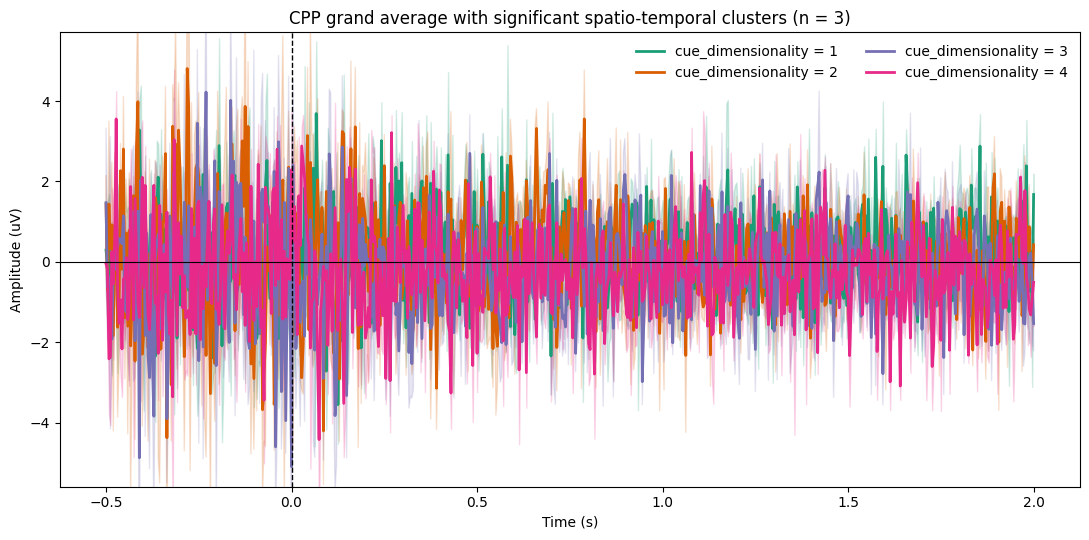

In [ ]:
condition_timecourses = {con: X[con - 1].mean(axis=2) for con in CONDITIONS}

plt.figure(figsize=(11, 5.5))

for con in CONDITIONS:
    mean_uv = condition_timecourses[con].mean(axis=0) * 1e6
    sem_uv = sem(condition_timecourses[con], axis=0) * 1e6
    plt.plot(times, mean_uv, color=COLORS[con], linewidth=2, label=f'cue_dimensionality = {con}')
    plt.fill_between(times, mean_uv - sem_uv, mean_uv + sem_uv, color=COLORS[con], alpha=0.18)

ymax = max((condition_timecourses[con].mean(axis=0) * 1e6).max() for con in CONDITIONS)
ymin = min((condition_timecourses[con].mean(axis=0) * 1e6).min() for con in CONDITIONS)     
line_y = ymax + 0.35
star_y = ymax + 0.48

for cluster_info in significant_clusters:
    plt.hlines(line_y, cluster_info['t_start'], cluster_info['t_end'], color='black', linewidth=2)
    plt.text((cluster_info['t_start'] + cluster_info['t_end']) / 2, star_y, '*', ha='center', va='bottom', fontsize=16, color='black')

plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.axhline(0, color='black', linewidth=0.8)
plt.ylim(ymin - 0.5, ymax + 0.9)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (uV)')
plt.title(f'CPP grand average with significant spatio-temporal clusters (n = {len(included_subjects)})')
plt.legend(frameon=False, ncol=2)
plt.tight_layout()
plt.show()


In [10]:
X[0].shape

(3, 641, 60)

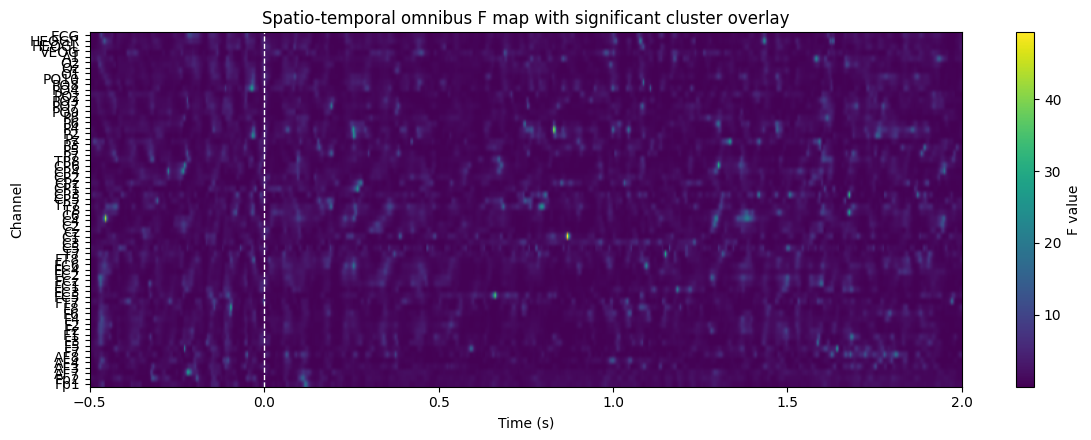

In [6]:
plt.figure(figsize=(12, 4.5))
plt.imshow(
    F_obs.T,
    aspect='auto',
    origin='lower',
    extent=[times[0], times[-1], -0.5, len(cpp_channel_names) - 0.5],
    cmap='viridis',
)
plt.colorbar(label='F value')

overlay = np.ma.masked_where(~significant_mask.T, significant_mask.T)
plt.imshow(
    overlay,
    aspect='auto',
    origin='lower',
    extent=[times[0], times[-1], -0.5, len(cpp_channel_names) - 0.5],
    cmap='autumn',
    alpha=0.6,
)

plt.axvline(0, color='white', linestyle='--', linewidth=1)
plt.yticks(np.arange(len(cpp_channel_names)), cpp_channel_names)
plt.xlabel('Time (s)')
plt.ylabel('Channel')
plt.title('Spatio-temporal omnibus F map with significant cluster overlay')
plt.tight_layout()
plt.show()
